# 屈折を考慮して、見かけの位置でGaussianを移動させ、レンダリングする


In [1]:
import os
import torch
import numpy as np
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.read_transformers import readNerfSyntheticCameras, fov2focal
from pathlib import Path
from mine.loader import initialize_model_from_ply_file

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

In [2]:
# Select the dataset
wo_refraction_dataset_path = os.path.abspath("../../../dataset/river1/river_wo-refraction")
with_refraction_dataset_path = os.path.abspath("../../../dataset/river1/river_with-refraction")
# Select trained model path
non_refraction_model_path = os.path.abspath('../results/river_wo-refraction/ply/point_cloud_29999.ply')


In [3]:
# Load the dataset
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loading 3D point cloud from: /home/taiki/dataset/river1/river_wo-refraction/points3d.ply
[Parser] Loaded 61 images from /home/taiki/dataset/river1/river_wo-refraction.


In [4]:
data = dataloader_ref.dataset[12]

# extract data
camtoworlds_original = data["camtoworld"].to(device)
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)


('train', '0012.png')


In [5]:
# camtoworlds (Blender to OpenGL)
# camtoworlds[:, :3, 1:3] *= -1
# camtoworlds[:, :3, 0] *= -1
# camtoworlds[:, :3, 2] *= -1
# camtoworlds[:, :3, :3] = torch.linalg.inv(camtoworlds[:, :3, :3])
camtoworlds[:, 0, 3] *= -1
print(camtoworlds)


tensor([[[ 1., -0., -0., -0.],
         [ 0., -1., -0.,  0.],
         [ 0., -0., -1., 30.],
         [ 0.,  0.,  0.,  1.]]], device='cuda:0')


In [6]:
# path of ply file
# file_path = os.path.abspath(os.path.join(os.path.expanduser("~"), "OneDrive", "3d_map_data", "20250327_simple-river", \
#     "20250327-1750_simple-river-cos_wo-refraction_env3_angle-40" , "postshot-no-initial-point", "mcmc.ply"))

# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)

In [7]:
gs_model_gt

VanillaGaussianModel(
  (gaussians): ParameterDict(
      (means): Parameter containing: [torch.cuda.FloatTensor of size 1000000x3 (cuda:0)]
      (opacities): Parameter containing: [torch.cuda.FloatTensor of size 1000000x1 (cuda:0)]
      (scales): Parameter containing: [torch.cuda.FloatTensor of size 1000000x3 (cuda:0)]
      (rotations): Parameter containing: [torch.cuda.FloatTensor of size 1000000x4 (cuda:0)]
      (shs): Parameter containing: [torch.cuda.FloatTensor of size 1000000x1x3 (cuda:0)]
  )
)

In [8]:
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]



# Refractionを考慮して座標変換

In [9]:
def transform_gaussian_point(point, cam_center, n=1.33, plane=0, atol=1e-8):
    """
    1点のGaussian中心 (world座標) を、カメラ中心および水面 z=plane を基準に屈折補正する。
    point: (x,y,z)
    cam_center: (x0,y0,H) カメラ位置（world座標）
    n: 屈折率（例: 水の場合 1.33）
    """
    # カメラ中心とのオフセット
    x0, y0, z0 = cam_center
    H = z0 - plane
    dx = point[0] - x0
    dy = point[1] - y0
    # 水面 z=plane に対する深さ。水中であれば h は負になる想定
    h = point[2] - plane  
    angle = np.arctan2(dy, dx)
    r = np.sqrt(dx**2 + dy**2)
    
    n2 = n**2
    H2 = H**2
    h2 = h**2
    r2 = r**2
    
    # 四次方程式の係数 (sに関する方程式)
    a4 = 1 - n2
    a3 = 2 * (n2 - 1) * r 
    a2 = (1 - n2) * (h2 + r2)
    a1 = 2 * n2 * r * H2
    a0 = - n2 * H2 * r2
    
    coeffs = [a4, a3, a2, a1, a0]
    s_roots = np.roots(coeffs)
    rs = 0  # デフォルト値
    # 実数解かつ s < r となる解を採用
    for s in s_roots:
        if np.abs(s.imag) < atol and s.real < r:
            rs = s.real
            break

    # 入射角 theta0, 屈折角 theta1 の計算
    theta0 = np.arctan(rs/H)
    theta1 = np.arctan((rs-r)/h)
    
    # 補正量の算出
    dr = - h * (n2 - 1) * (np.tan(theta1)**3)  # r の補正 (> 0)
    ra = r - dr
    A = np.sqrt(1 - n2 * (np.sin(theta1)**2))**3
    za = h * A / (n * (np.cos(theta1)**3))    # (< 0)
    
    # 水平方向の補正 (カメラ中心からのずれ)
    dx_app = ra * np.cos(angle)
    dy_app = ra * np.sin(angle)
    
    # 見かけ上の位置 (world座標)
    new_x = x0 + dx_app
    new_y = y0 + dy_app
    new_z = plane + za
    
    return np.array([new_x, new_y, new_z])
    

In [10]:
def transform_all_gaussians(means_np, cam_center, n=1.33, plane=0, atol=1e-8):
    """
    全てのGaussian中心 (numpy 配列, shape: [N,3]) に対して屈折変換を適用する。
    """
    new_means = []
    for i in range(means_np.shape[0]):
        new_point = transform_gaussian_point(means_np[i], cam_center, n, plane, atol)
        new_means.append(new_point)
    return np.stack(new_means, axis=0)

In [11]:
# Culling
def culling_points(points, W2C, K, width, height):
    """
    点群(points: [N,3])を、カメラの視錐台内にあるかで判定する。
    1. 点を同次座標に拡張して W2C でカメラ座標系に変換
    2. カメラ座標での深度 (z) > 0 であることを確認
    3. K を用いて画像平面に射影し、(u,v) が画像サイズ内にあるか判定
    """
    
    N = points.shape[0]
    points_h = np.concatenate([points, np.ones((N,1))], axis=1) # [N, 4]
    
    # convert to camera coordinate
    points_cam = (W2C @ points_h.T).T
    points_cam = points_cam[:, :3]
    
    # get points in front of camera
    valid_depth = points_cam[:, 2] > 0
    
    # project to image plane
    proj = (K @ points_cam.T).T
    proj = proj / proj[:, 2:3] # normalize by z
    u = proj[:, 0]
    v = proj[:, 1]
    
    valid_u = (u >= 0) & (u < width)
    valid_v = (v >= 0) & (v < height)
    
    mask = valid_depth & valid_u & valid_v
    
    return mask.squeeze()



In [12]:
# --- メイン処理 ---
# 元のGaussian中心を numpy 配列に変換
means_np = means.cpu().detach().numpy()
# カメラ中心 (cam.T) はworld 座標。必要に応じ numpy 配列に変換
cam_center_np = camtoworlds[0, :3, 3].cpu().detach().numpy()  # [3,]

# Get Gaussians in the camera frustum
mask = culling_points(means_np, 
                      camtoworlds.cpu().detach().numpy(), 
                      Ks.cpu().detach().numpy(), 
                      width, 
                      height)
print(f"Culling: {np.sum(mask)} / {mask.shape[0]} points are in the camera frustum")

means_np_culled = means_np[mask]
mask_tensor = torch.from_numpy(mask).to(device)

quats_culled = quats[mask]
scales_culled = scales[mask]
opacities_culled = opacities[mask]
colors_culled = colors[mask]

Culling: 272981 / 1000000 points are in the camera frustum


In [13]:
# カリングされた点のみ屈折補正を実施
transformed_means_np = transform_all_gaussians(means_np_culled, cam_center_np, n=1.33, plane=0, atol=1e-8)

# 変換後のGaussian中心をtorch.Tensorに変換し、deviceに配置
transformed_means = torch.from_numpy(transformed_means_np).to(device).float()

# 補正済みの点 (mask True の部分) を元の点群に埋め込む
transformed_means_full = torch.from_numpy(means_np).to(device).float()
transformed_means_full[mask_tensor] = transformed_means
transformed_means = transformed_means_full

/tmp/ipykernel_1849796/2601847049.py:46: RuntimeWarning: invalid value encountered in sqrt
  A = np.sqrt(1 - n2 * (np.sin(theta1)**2))**3


In [14]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    camtoworlds,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [15]:
# 補正後の Gaussian を用いてレンダリング
rgb_refraction, _, _ = rasterization(
    transformed_means_full,
    quats,
    scales,
    opacities,
    colors,
    camtoworlds,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction = rgb_refraction.squeeze().cpu().detach().numpy()


GT image without refraction: /home/taiki/dataset/river1/river_wo-refraction/train/0012.png
GT image with refraction: /home/taiki/dataset/river1/river_with-refraction/train/0012.png


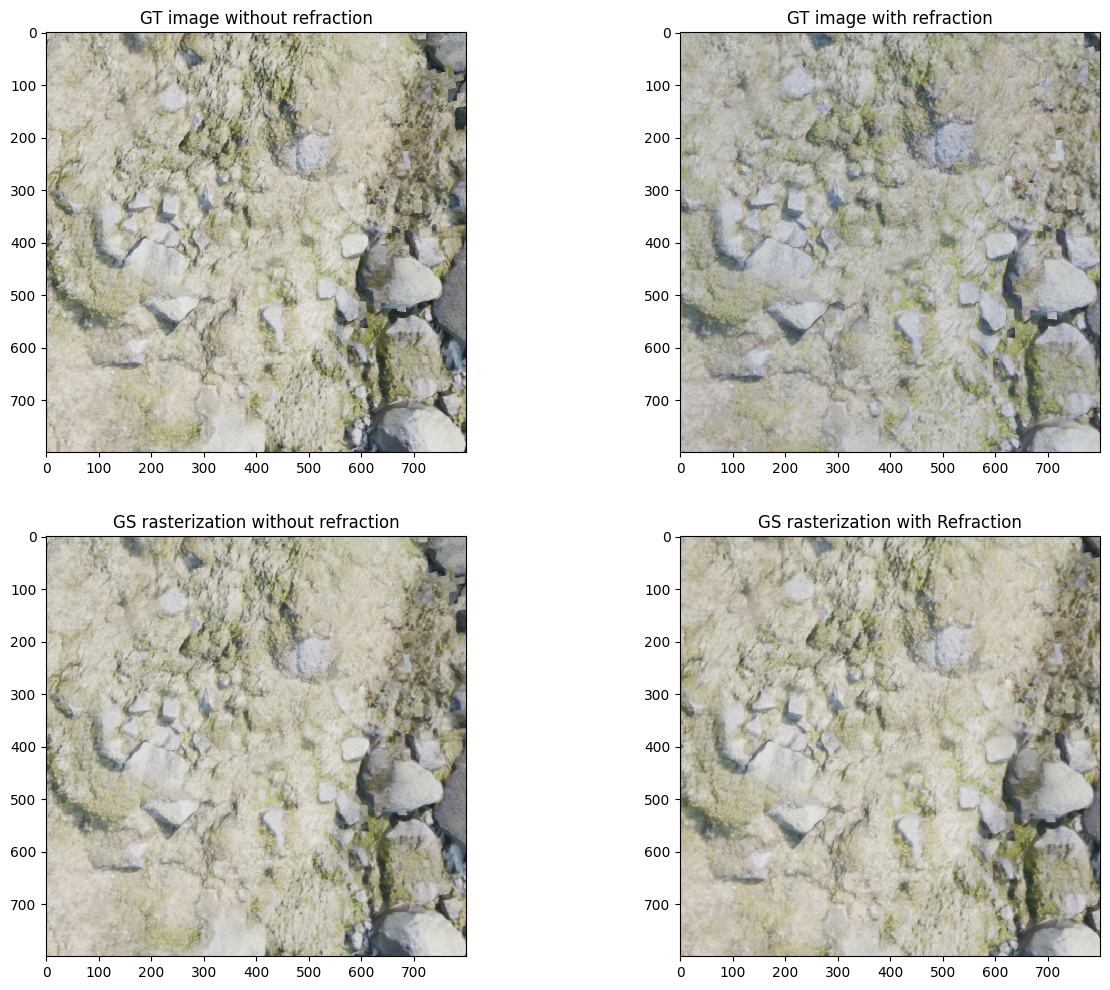

In [17]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction)
ax[1, 1].set_title("GS rasterization with Refraction")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06858642..1.1054575].


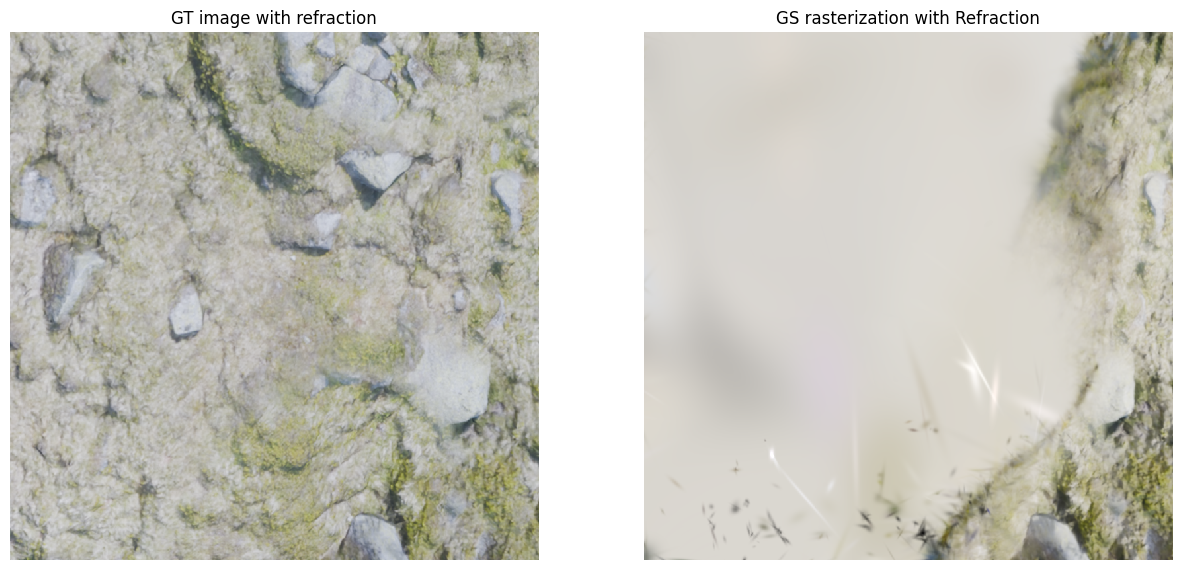

In [ ]:
fig, ax = plt.subplots(1, 2)
# no axis
ax[0].axis("off")
ax[0].imshow(gt_image_with_ref)
ax[0].set_title("GT image with refraction")
ax[1].axis("off")
ax[1].imshow(rgb_refraction)
ax[1].set_title("GS rasterization with Refraction")

plt.show()